# 04 — Standalone class-conditioned ResNet baseline

This compact notebook is the reusable training entry point for one shared
normal/defective classifier across all product categories.

Each sample contains:

1. A YOLO-segmented object crop.
2. Its known product class.
3. A binary normal/defective target.

The class embedding controls spatial attention and FiLM feature modulation.
Splits are grouped by source image, the threshold is selected on validation
data, and final reporting uses the held-out test set only.

> Use notebook 03 when you also need to build the augmented balanced dataset.
> Use this notebook when that dataset/metadata already exists.


## 1. Locate and import the reusable training module

The helper module owns dataset loading, grouped splitting, training, metrics,
plots, checkpoint serialization, and single-image prediction.


In [1]:
# Resolve conditional_resnet.py and import its public workflow
from pathlib import Path
import sys

here = Path.cwd().resolve()
candidates = [here, here / "misc" / "ridac"]
candidates.extend(parent / "misc" / "ridac" for parent in here.parents)
MODULE_DIR = next(
    (path for path in dict.fromkeys(candidates) if (path / "conditional_resnet.py").is_file()),
    None,
)
if MODULE_DIR is None:
    raise FileNotFoundError("Could not locate misc/ridac/conditional_resnet.py")
sys.path.insert(0, str(MODULE_DIR))

from conditional_resnet import Config, load_trained_model, predict_image, run_training


## 2. Configure the baseline

ResNet18 is the fastest baseline. `resnet34` and `resnet50` are available when
additional capacity is justified. ImageNet weights may be downloaded on the
first run if they are not already cached.

The backbone learning rate is reduced to 20% of the classification-head rate,
which protects transferred visual features during fine-tuning.


In [2]:
# Define the reproducible ResNet experiment configuration
# The complete configuration is stored with the final checkpoint.
config = Config(
    backbone="resnet18",
    pretrained=True,
    image_size=224,
    batch_size=64,
    epochs=30,
    early_stopping_patience=7,
    learning_rate=3e-4,
    backbone_lr_multiplier=0.20,
    weight_decay=1e-4,
    dropout=0.30,
    embedding_dim=128,
    label_smoothing=0.02,
    seed=42,
)
config


Config(ridac_dir=PosixPath('/home/student/Deep-Mtech/misc/ridac'), output_dir_name='conditional_resnet_results', backbone='resnet18', pretrained=True, image_size=224, batch_size=64, epochs=30, early_stopping_patience=7, learning_rate=0.0003, backbone_lr_multiplier=0.2, weight_decay=0.0001, dropout=0.3, embedding_dim=128, label_smoothing=0.02, num_workers=8, seed=42, test_folds=5, val_folds=5, compile_model=False)

## 3. Train, validate, test, and save artifacts

`run_training` performs the full experiment:

- Loads valid object-crop metadata.
- Creates leakage-safe grouped splits.
- Uses a class/label-balanced training sampler.
- Trains with early stopping.
- Selects an F1-optimal threshold on validation data.
- Evaluates the test set once.
- Saves the checkpoint, plots, predictions, and metrics.


Loaded 34,111 crops from full_results.csv
assigned_label      defective  normal
split source_class                   
test  candle               21     859
      capsules             22    2788
      cashew               20     100
      chewinggum           20     101
      fryum                20     100
      macaroni1            21     859
      macaroni2            20     860
      pcb1                 19     202
      pcb2                 20     200
      pcb3                 20     201
      pcb4                 20     201
      pipe_fryum           21     100
train candle               69    2747
      capsules             71    8940
      cashew               64     320
      chewinggum           64     323
      fryum                64     320
      macaroni1            67    2749
      macaroni2            65    2753
      pcb1                 62     645
      pcb2                 64     641
      pcb3                 64     644
      pcb4                 64     644
      pi

train:   0%|          | 0/342 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 01/30: loss=0.2954/0.1066, PR-AUC=0.9590/0.7558


train:   0%|          | 0/342 [00:00<?, ?it/s]

...

train:   0%|          | 0/342 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 25/30: loss=0.0580/0.0351, PR-AUC=1.0000/0.9197
Early stopping after epoch 25; best validation PR-AUC=0.9292


predict:   0%|          | 0/86 [00:00<?, ?it/s]

predict:   0%|          | 0/107 [00:00<?, ?it/s]

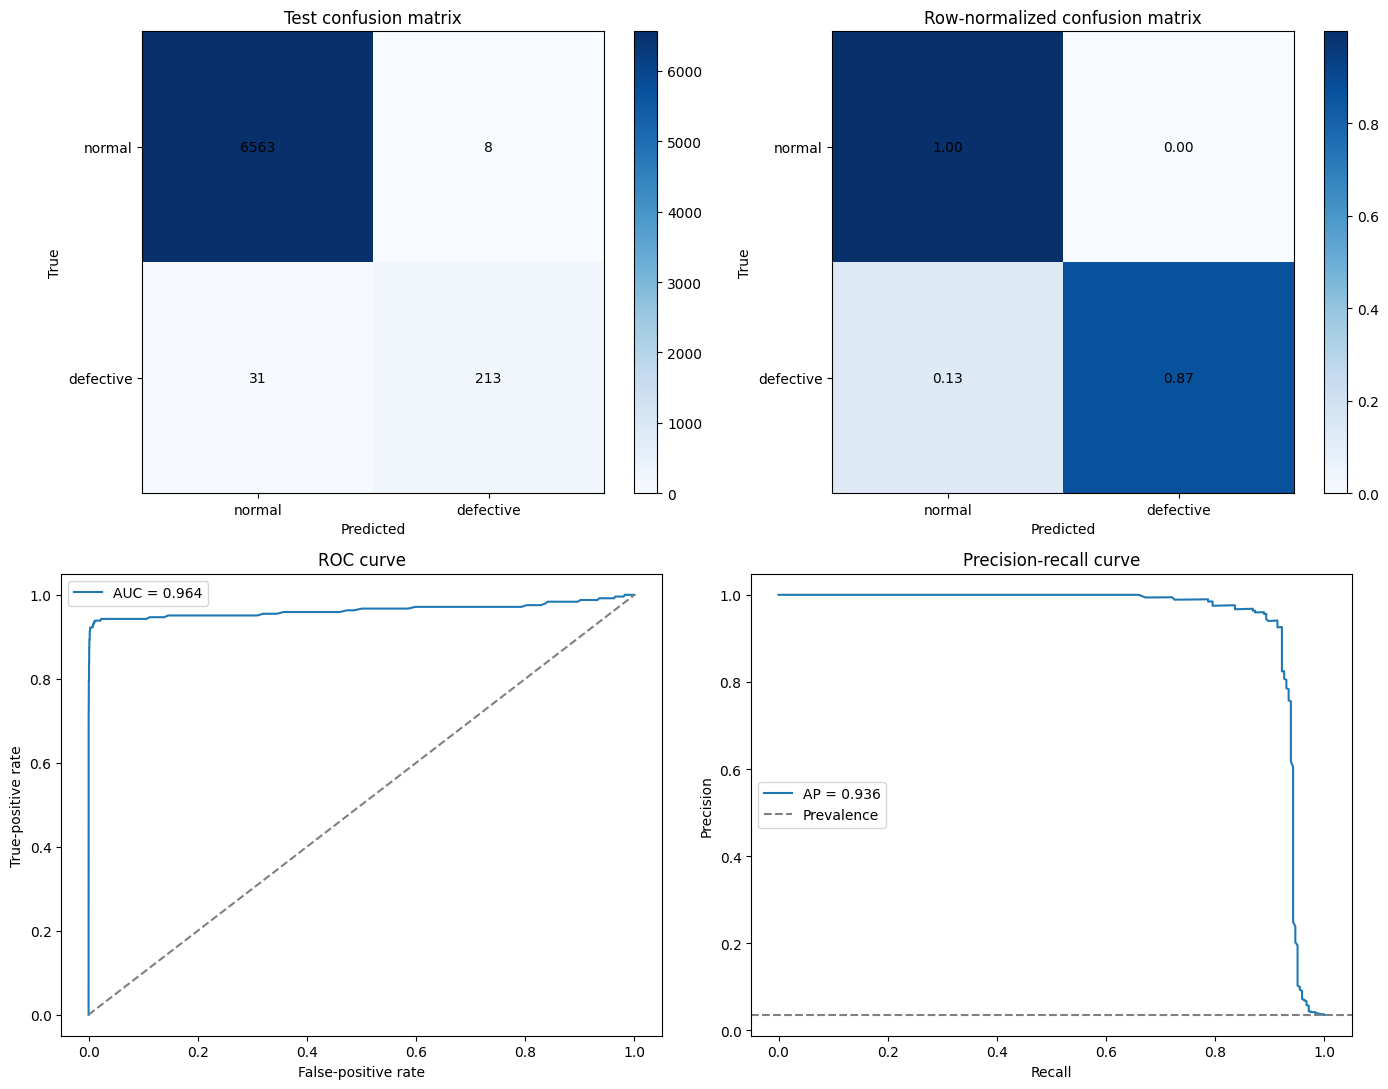

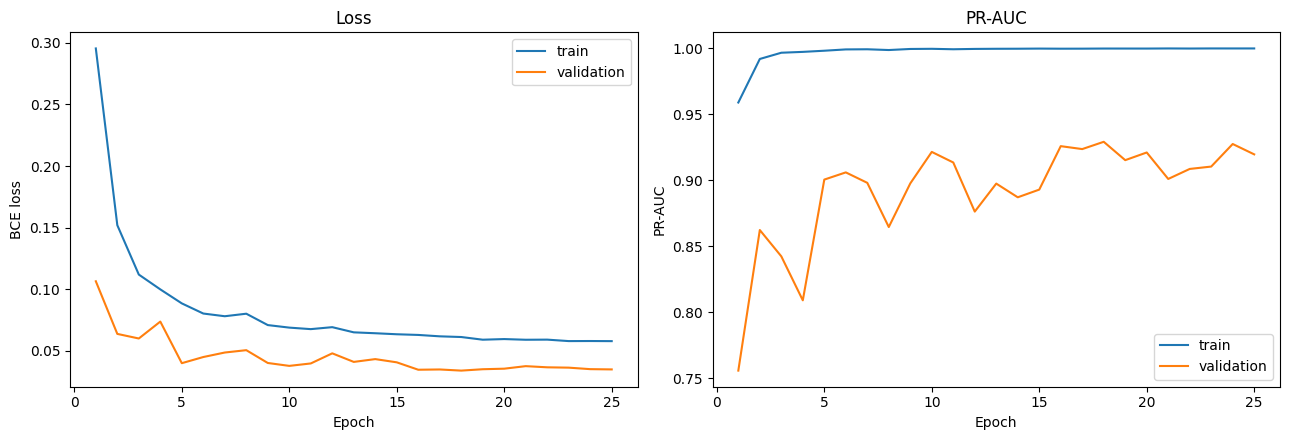

Best model and reports saved to /home/student/Deep-Mtech/misc/ridac/object_defect_dataset/conditional_resnet_results


In [3]:
# Execute the complete ResNet training and evaluation workflow
artifacts = run_training(config)


## 4. Inspect the evaluation summary

Review defective recall, F1, MCC, and PR-AUC alongside accuracy. Per-class
metrics reveal whether a product category is underrepresented even when the
overall score is high.


In [4]:
# Display overall and per-class metrics plus the selected threshold
from IPython.display import display

display(artifacts["overall_metrics"].T.rename(columns={"overall": "value"}))
display(
    artifacts["per_class_metrics"][[
        "samples", "accuracy", "balanced_accuracy", "precision",
        "recall_sensitivity", "specificity", "f1", "mcc", "roc_auc", "pr_auc",
    ]]
)
print("Selected validation threshold:", artifacts["threshold"])
print("Reports:", artifacts["config"].output_dir)


,value
samples,6815.000000
threshold,0.834961
accuracy,0.994277
balanced_accuracy,0.935867
precision,0.963801
recall_sensitivity,0.872951
specificity,0.998783
negative_predictive_value,0.995299
f1,0.916129
mcc,0.914374


,samples,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,mcc,roc_auc,pr_auc
source_class,,,,,,,,,,
candle,880,0.994318,0.927407,0.900000,0.857143,0.997672,0.878049,0.875415,0.977632,0.926890
capsules,2810,0.997865,0.953828,0.833333,0.909091,0.998565,0.869565,0.869327,0.999609,0.950002
cashew,120,0.983333,0.970000,0.950000,0.950000,0.990000,0.950000,0.940000,0.999500,0.997619
chewinggum,121,0.991736,0.975000,1.000000,0.950000,1.000000,0.974359,0.969890,0.967079,0.961494
fryum,120,0.966667,0.900000,1.000000,0.800000,1.000000,0.888889,0.877058,0.954000,0.951265
macaroni1,880,0.998864,0.999418,0.954545,1.000000,0.998836,0.976744,0.976440,0.999945,0.997835
macaroni2,880,0.997727,0.950000,1.000000,0.900000,1.000000,0.947368,0.947582,0.958401,0.948859
pcb1,221,0.990950,0.947368,1.000000,0.894737,1.000000,0.944444,0.941257,0.908286,0.904717
pcb2,220,0.986364,0.925000,1.000000,0.850000,1.000000,0.918919,0.915117,0.996375,0.971435


Selected validation threshold: 0.8349609375
Reports: /home/student/Deep-Mtech/misc/ridac/object_defect_dataset/conditional_resnet_results


## 5. Predict one held-out crop and visualize attention

The example comes from the test predictions table. In production, the product
class should come from the upstream YOLO segmentation result.


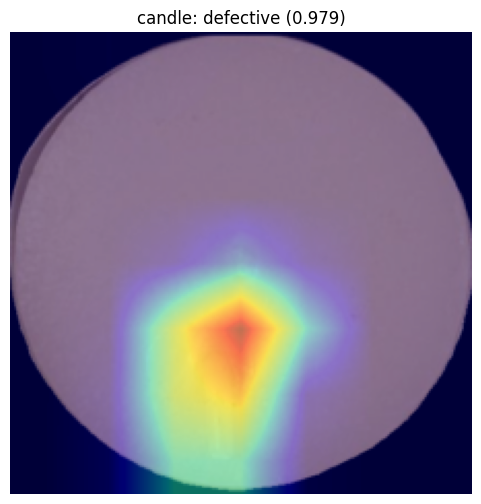

{'class_name': 'candle',
 'predicted_label': 'defective',
 'probability_defective': 0.9792718291282654,
 'threshold': 0.8349609375}

In [10]:
# Run one class-conditioned prediction with an attention overlay
example = artifacts["test_predictions"].iloc[10]
prediction = predict_image(
    model=artifacts["model"],
    image_path=example["crop_path"],
    class_name=example["source_class"],
    class_to_idx=artifacts["class_to_idx"],
    transform=artifacts["eval_transform"],
    device=artifacts["device"],
    threshold=artifacts["threshold"],
    show_attention=True,
)
prediction


## 6. Reload the checkpoint for later inference

The checkpoint contains model weights, class-to-index mapping, preprocessing
configuration, and the validation-selected threshold. A valid `class_name` is
mandatory for every prediction.


In [6]:
# Load the saved bundle without retraining
checkpoint_path = config.output_dir / "best_conditional_resnet.pt"
bundle = load_trained_model(checkpoint_path)

# Example deployment call:
# result = predict_image(
#     model=bundle["model"],
#     image_path="path/to/object_crop.png",
#     class_name="pcb1",
#     class_to_idx=bundle["class_to_idx"],
#     transform=bundle["eval_transform"],
#     device=bundle["device"],
#     threshold=bundle["threshold"],
#     show_attention=True,
# )
print("Loaded classes:", bundle["class_to_idx"])


Loaded classes: {'candle': 0, 'capsules': 1, 'cashew': 2, 'chewinggum': 3, 'fryum': 4, 'macaroni1': 5, 'macaroni2': 6, 'pcb1': 7, 'pcb2': 8, 'pcb3': 9, 'pcb4': 10, 'pipe_fryum': 11}


## Expected artifacts

The configured output directory contains:

- `best_conditional_resnet.pt`
- `overall_metrics.csv`
- `per_class_metrics.csv`
- `training_history.csv`
- `training_curves.png`
- `test_evaluation.png`
- Validation and test prediction CSVs
